<a href="https://colab.research.google.com/github/7500nidhi/Artificial_Intelligence_Course/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [3]:
# Load Dataset

df = pd.read_csv("/content/customer_churn_dataset.csv")

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
# Check Dataset
print("Shape of the dataset: ",df.shape)

print("\n","Information of the dataset: ")
print(df.info())

print("\n","Statistical summary: ")
print(df.describe().round(2).to_string())

Shape of the dataset:  (64374, 12)

 Information of the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
None

 Statistical summary: 
       CustomerID       Age    Tenure  Usage Frequency  Support Calls  Payment Delay  To

In [5]:
# Check Missing Values
print("Missing values: ",df.isnull().sum())

# Check duplicate records
print("\n","duplicate records: ",df.duplicated().sum())


Missing values:  CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

 duplicate records:  0


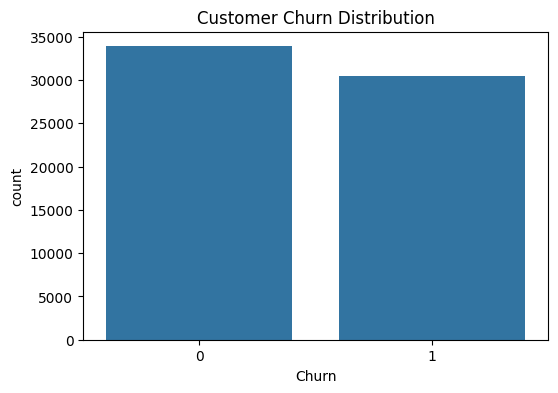

In [6]:
# ************************************Exploratory Data Analysis********************************************

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

**Observation:** The chart shows the distribution of customers who stayed and customers who churned. Customers with Churn = 0 (did not leave) are slightly more than customers with Churn = 1 (left the company). This indicates that the dataset is fairly balanced, with a similar number of customers in both classes, making it suitable for building and evaluating a machine learning model.

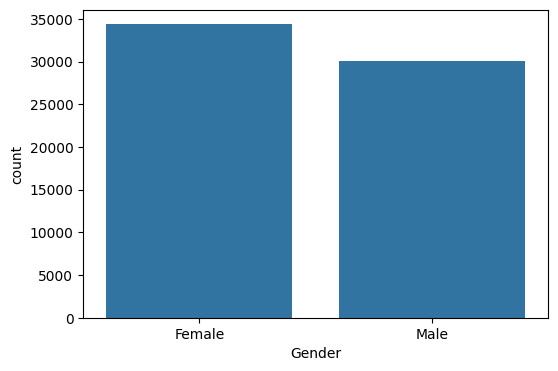

In [ ]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.show()

**Observation:** The chart shows the distribution of customers by gender. There are slightly more female customers than male customers in the dataset. However, the difference is small, indicating that both genders are well represented. This balanced distribution helps the machine learning model learn from data without being heavily influenced by one gender.

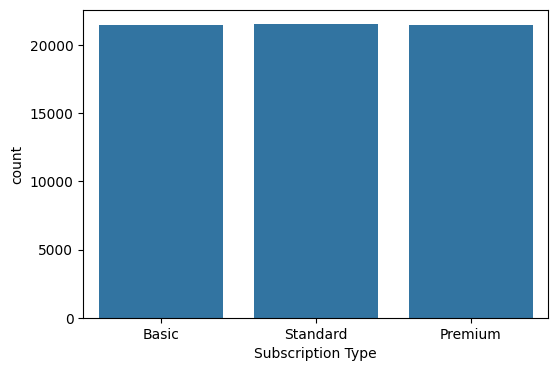

In [ ]:
# Subscription Type
plt.figure(figsize=(6,4))
sns.countplot(x='Subscription Type', data=df)
plt.show()

**Observation:** The chart shows the distribution of customers across the three subscription types: Basic, Standard, and Premium. The number of customers in each subscription type is almost the same, indicating that the dataset is well balanced. This balanced distribution helps the machine learning model learn fairly from all subscription categories without favoring one over another.

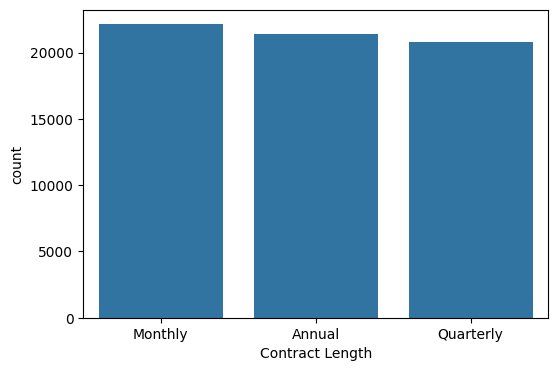

In [ ]:
# Contract Length
plt.figure(figsize=(6,4))
sns.countplot(x='Contract Length', data=df)
plt.show()

**Observation:** The chart shows the number of customers for each contract length: Monthly, Annual, and Quarterly. Monthly contracts have the highest number of customers, while Quarterly contracts have the lowest. However, the differences are small, indicating that all three contract types are well represented in the dataset. This provides a balanced distribution for training the machine learning model.

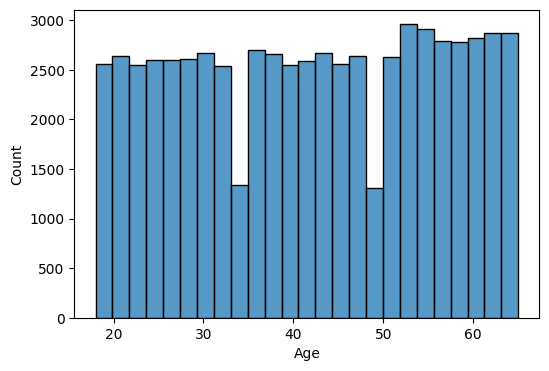

In [ ]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=25)
plt.show()

**Observation:** The histogram shows the distribution of customer ages in the dataset. Customers range from about 18 to 65 years old, and the ages are spread fairly evenly across this range. There are no major peaks or gaps, indicating that the dataset includes customers from different age groups. This balanced age distribution helps the machine learning model learn from a diverse set of customers.

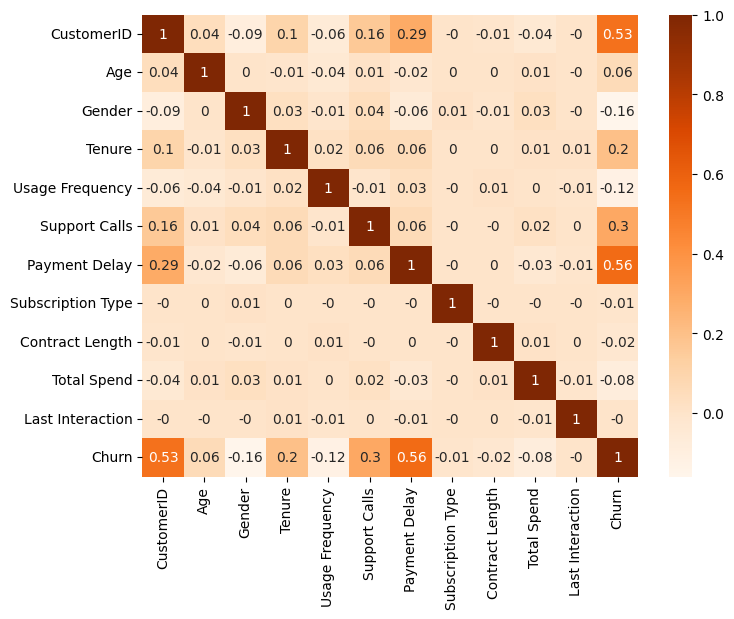

In [11]:
# Correlation Heatmap
temp = df.copy()
encoder = LabelEncoder()

temp['Gender'] = encoder.fit_transform(temp['Gender'])
temp['Subscription Type'] = encoder.fit_transform(temp['Subscription Type'])
temp['Contract Length'] = encoder.fit_transform(temp['Contract Length'])

corr = temp.corr(numeric_only=True).round(2)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Oranges")
plt.show()

**Observation:** The correlation heatmap shows the relationship between the features in the dataset and the target variable (Churn). Most features have weak correlations with each other, indicating that there is little multicollinearity. Payment Delay (0.56) has the strongest positive correlation with customer churn, followed by Support Calls (0.30) and Tenure (0.20). Usage Frequency (-0.12) and Gender (-0.16) have weak negative correlations with churn. Overall, no single feature strongly determines customer churn, so the machine learning model will learn by combining information from multiple features.

In [12]:
# ********************************Data Preprocessing*********************************************

# Drop CustomerID
df.drop("CustomerID", axis=1, inplace=True)

# Encode categorical variables

gender_encoder = LabelEncoder()
subscription_encoder = LabelEncoder()
contract_encoder = LabelEncoder()

df['Gender'] = gender_encoder.fit_transform(df['Gender'])
df['Subscription Type'] = subscription_encoder.fit_transform(df['Subscription Type'])
df['Contract Length'] = contract_encoder.fit_transform(df['Contract Length'])

**Observation:** In this preprocessing step, the CustomerID column is removed because it is only a unique identifier and does not help predict customer churn. The categorical features Gender, Subscription Type, and Contract Length are converted into numerical values using separate LabelEncoder objects. This allows the machine learning models to process these features correctly and improves the reliability of the prediction process.

In [13]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
# Scale numerical features
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42, stratify=y)

In [16]:
#************************************Model Building****************************************************

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

**Observation:** In this step, three machine learning models—Decision Tree, Random Forest, and Support Vector Machine (SVM)—are trained using the training dataset. After training, each model is used to make predictions on the test dataset. These predictions will be evaluated in the next step to compare the performance of the models and identify the best one for customer churn prediction.

In [17]:
# Model Evaluation

# Create a reusable function.
def evaluate(model, prediction):
    print(model)
    print("Accuracy :", accuracy_score(y_test, prediction))
    print()
    print(classification_report(y_test, prediction))
    cm = confusion_matrix(y_test, prediction)
    ConfusionMatrixDisplay(cm).plot()
    plt.show()

**Observation:** In this step, a reusable function is created to evaluate each machine learning model. The function calculates the accuracy of the model, displays a classification report (including precision, recall, and F1-score), and plots a confusion matrix. These evaluation metrics help compare the performance of the Decision Tree, Random Forest, and SVM models and identify the model that predicts customer churn most accurately.

Decision Tree
Accuracy : 0.9992233009708738

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



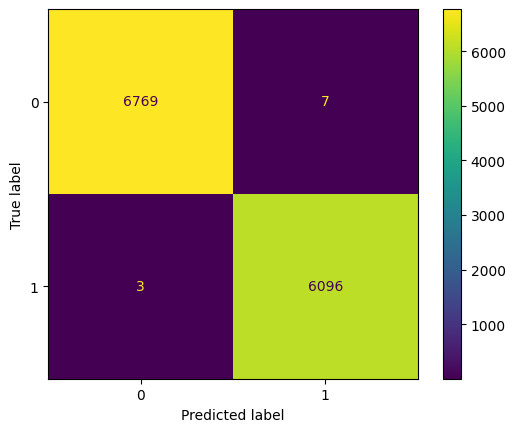

Random Forest
Accuracy : 0.9989902912621359

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



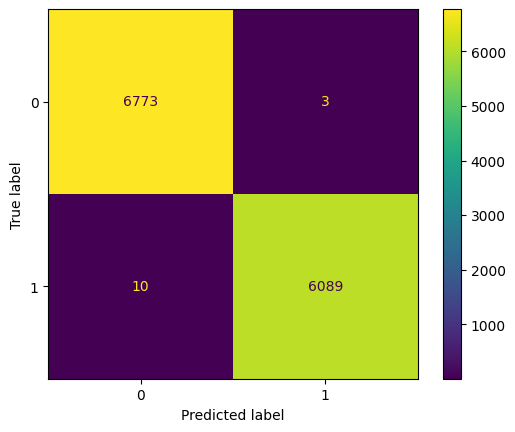

SVM
Accuracy : 0.9415922330097087

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      6776
           1       0.92      0.96      0.94      6099

    accuracy                           0.94     12875
   macro avg       0.94      0.94      0.94     12875
weighted avg       0.94      0.94      0.94     12875



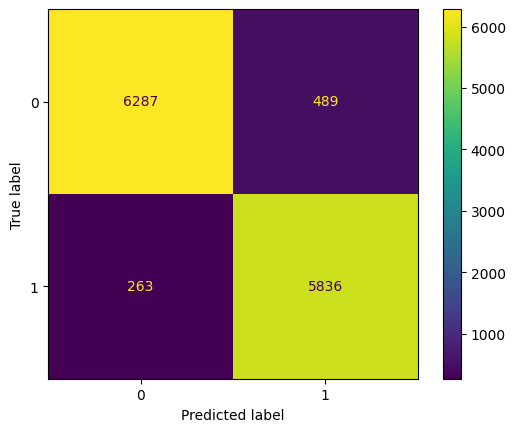

In [18]:
# Evaluate all models.
evaluate("Decision Tree", dt_pred)
evaluate("Random Forest", rf_pred)
evaluate("SVM", svm_pred)

**Observation: **The performance of the three machine learning models was compared using accuracy, the classification report, and the confusion matrix. The Decision Tree achieved the highest accuracy (99.92%), followed closely by the Random Forest (99.90%), while the Support Vector Machine (SVM) achieved 94.16% accuracy. The confusion matrices show that the Decision Tree and Random Forest made very few incorrect predictions, whereas the SVM made more classification errors. Overall, the Decision Tree performed the best on this dataset, making it the most effective model for predicting customer churn.

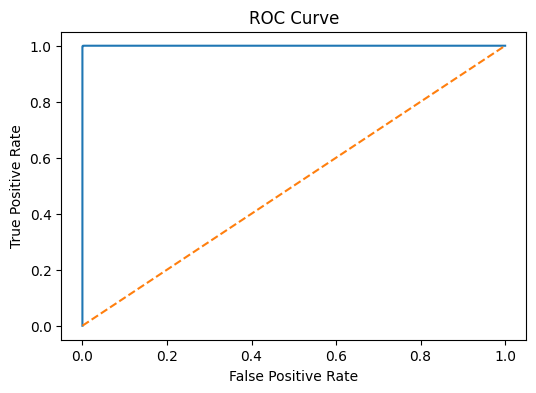

ROC-AUC: 0.9999970721195512


In [19]:
# ROC Curve
rf_probability = rf.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, rf_probability)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, rf_probability))

**Observation:** The ROC curve shows that the model performs very well in distinguishing between customers who will churn and those who will not. The curve is very close to the top-left corner, and the ROC-AUC score of 0.999997 is almost 1.0, indicating excellent classification performance. This means the model can accurately identify customers at risk of churning with very few prediction errors.

In [20]:
# Hyperparameter Tuning
parameters = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train,y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [21]:
# Best Model
best_model = grid.best_estimator_
best_prediction = best_model.predict(X_test)
print(classification_report(y_test,best_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



**Observation:** After hyperparameter tuning with GridSearchCV, the best-performing model was selected and evaluated on the test data. The classification report shows 100% accuracy, with precision, recall, and F1-score of 1.00 for both classes. This indicates that the optimized model correctly classified almost all customers, making it highly effective for predicting customer churn.

In [22]:
# Cross Validation
scores = cross_val_score(best_model,X,y,cv=5)
print(scores)
print("Average Accuracy:", scores.mean())

[0.99930097 0.99961165 0.99953398 0.99961165 0.9996893 ]
Average Accuracy: 0.9995495097366408


**Observation:** The cross-validation results show that the model performs consistently well across all five data splits, with accuracy values very close to 100%. The average accuracy of 99.95% indicates that the model is stable, reliable, and generalizes well to new data, making it a strong choice for predicting customer churn.

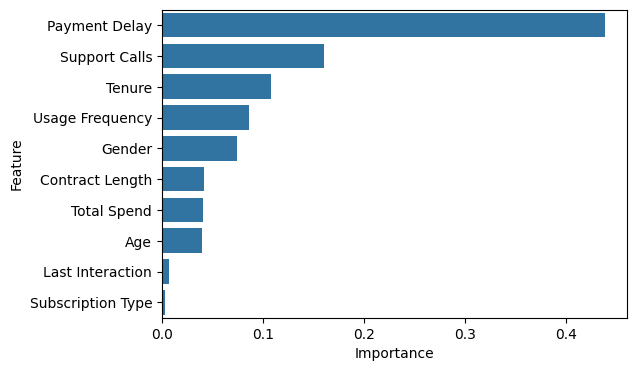

In [23]:
 # Feature Importance
importance = pd.DataFrame({
    "Feature": df.drop("Churn",axis=1).columns,
    "Importance": best_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.show()

**Observation:** The feature importance chart shows which factors have the greatest influence on predicting customer churn. Payment Delay is the most important feature, followed by Support Calls, Tenure, and Usage Frequency. Features such as Subscription Type and Last Interaction have very little impact on the prediction. This indicates that customer payment behavior and service usage are the strongest factors affecting churn in this dataset.

In [28]:
def predict_customer():

    age = float(input("Age: "))
    gender = input("Gender (Female/Male): ").strip()
    tenure = float(input("Tenure: "))
    usage = float(input("Usage Frequency: "))
    support = float(input("Support Calls: "))
    payment = float(input("Payment Delay: "))
    subscription = input("Subscription (Basic/Premium/Standard): ").strip()
    contract = input("Contract (Annual/Monthly/Quarterly): ").strip()
    spend = float(input("Total Spend: "))
    interaction = float(input("Last Interaction: "))

    # Encode categorical variables
    gender = gender_encoder.transform([gender])[0]
    subscription = subscription_encoder.transform([subscription])[0]
    contract = contract_encoder.transform([contract])[0]

    # Create input dataframe
    input_data = pd.DataFrame({
        'Age': [age],
        'Gender': [gender],
        'Tenure': [tenure],
        'Usage Frequency': [usage],
        'Support Calls': [support],
        'Payment Delay': [payment],
        'Subscription Type': [subscription],
        'Contract Length': [contract],
        'Total Spend': [spend],
        'Last Interaction': [interaction]
    })

    # Scale the input
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = best_model.predict(input_scaled)

    if prediction[0] == 1:
        print("\nCustomer is likely to Churn")
    else:
        print("\nCustomer is likely to Stay")

In [29]:
predict_customer()

Age: 35
Gender (Female/Male): Female
Tenure: 24
Usage Frequency: 15
Support Calls: 2
Payment Delay: 5
Subscription (Basic/Premium/Standard): Premium
Contract (Annual/Monthly/Quarterly): Annual
Total Spend: 1200
Last Interaction: 10

Customer is likely to Stay


**Observation:** The interactive prediction system allows users to enter customer information, such as age, tenure, payment delay, and subscription details, and receive a churn prediction from the trained machine learning model. In this example, after entering the customer details, the model predicted that the customer is likely to stay. This demonstrates that the trained model can be used interactively in Google Colab to make real-time customer churn predictions.

**Conclusion:** In this project, machine learning techniques were used to predict customer churn using customer demographic, subscription, and usage data. The dataset was cleaned, preprocessed, and explored using different visualizations. Three models—Decision Tree, Random Forest, and Support Vector Machine (SVM)—were trained and evaluated. The Decision Tree achieved the highest accuracy, followed closely by the Random Forest, while the SVM also performed well but with lower accuracy. Hyperparameter tuning and cross-validation further improved the model's performance and confirmed its reliability. The feature importance analysis showed that Payment Delay and Support Calls were the most important factors affecting customer churn. Finally, an interactive prediction system was created in Google Colab, allowing users to enter customer information and receive real-time churn predictions. Overall, the project successfully developed an accurate and reliable customer churn prediction model.